# NB_C2 — NOTEARS Causal DAG

**Method:** NOTEARS (Zheng et al. 2018 NeurIPS) — exact implementation
with matrix exponential acyclicity constraint.

**What this does:**
Learns a directed acyclic graph from HMP2 longitudinal microbiome data.
X = CLR abundances at time t, Y = CLR abundances at time t+1.
Temporal structure gives directionality — A→B means A at time t
predicts B at time t+1.
Runs on 29 keystone species (union of top-15 from CD, UC, Healthy).
29 species = feasible with exact algorithm (~10-20 min on Colab CPU).

**Files to upload to Drive before running:**
- `notears_X.csv` — from NB1 data/processed/
- `notears_Y.csv` — from NB1 data/processed/
- `notears_species.csv` — from NB1 data/processed/
- `keystones_CD.csv` — from results/networks/
- `keystones_UC.csv` — from results/networks/
- `keystones_Healthy.csv` — from results/networks/

**Downloads after → put in `data/processed/causal/`:**
- `W_est.csv` — full adjacency matrix
- `W_est_thresholded.csv` — thresholded adjacency matrix
- `causal_edges.csv` — edge list with weights
- `notears_keystone_species.csv` — species used in DAG
- `Fig_causal_DAG.png` — network figure

In [1]:
!pip install git+https://github.com/xunzheng/notears.git -q
!pip install numpy scipy pandas scikit-learn networkx matplotlib -q
print("Done")

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 51.7 MB/s eta 0:00:00
Done


In [2]:
from google.colab import drive
drive.mount('/content/drive')
import os

PROJECT   = '/content/drive/MyDrive/CECE_data_external'
SAVE_PATH = '/content/drive/MyDrive/CECE_results'
os.makedirs(f'{SAVE_PATH}/causal', exist_ok=True)

required = [
    'notears_X.csv',
    'notears_Y.csv',
    'notears_species.csv',
    'keystones_CD.csv',
    'keystones_UC.csv',
    'keystones_Healthy.csv'
]

all_ok = True
for f in required:
    exists = os.path.exists(f'{PROJECT}/{f}')
    status = 'YES' if exists else 'MISSING'
    print(f'  {f}: {status}')
    if not exists:
        all_ok = False

print()
if all_ok:
    print('All files present')
else:
    print('ERROR: Upload missing files to Drive before continuing')

Mounted at /content/drive
  notears_X.csv: YES
  notears_Y.csv: YES
  notears_species.csv: YES
  keystones_CD.csv: YES
  keystones_UC.csv: YES
  keystones_Healthy.csv: YES

All files present


In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

X_full   = pd.read_csv(f'{PROJECT}/notears_X.csv').values
species  = pd.read_csv(f'{PROJECT}/notears_species.csv',
                        header=None)[0].tolist()

print(f'Full data: {X_full.shape}  ({len(species)} species)')
print(f'NaN check: {np.isnan(X_full).sum()}')

ks_cd      = pd.read_csv(f'{PROJECT}/keystones_CD.csv')
ks_uc      = pd.read_csv(f'{PROJECT}/keystones_UC.csv')
ks_healthy = pd.read_csv(f'{PROJECT}/keystones_Healthy.csv')

keystone_species = sorted(set(
    ks_cd.head(15)['species'].tolist() +
    ks_uc.head(15)['species'].tolist() +
    ks_healthy.head(15)['species'].tolist()
))

keystone_species = [sp for sp in keystone_species if sp in species]

print(f'\nKeystone species selected: {len(keystone_species)}')
print('(union of top-15 from CD, UC, Healthy conditions)')

col_idx  = [species.index(sp) for sp in keystone_species]
X_ks     = X_full[:, col_idx]

print(f'\nX_keystone shape: {X_ks.shape}')

scaler = StandardScaler()
X_std  = scaler.fit_transform(X_ks)

print(f'X_std mean: {X_std.mean():.6f}')
print(f'X_std std:  {X_std.std():.4f}')

print(f'\nFirst 5 keystone species:')
for sp in keystone_species[:5]:
    print(f'  {sp}')

Full data: (568, 87)  (87 species)
NaN check: 0

Keystone species selected: 29
(union of top-15 from CD, UC, Healthy conditions)

X_keystone shape: (568, 29)
X_std mean: 0.000000
X_std std:  1.0000

First 5 keystone species:
  Alistipes_finegoldii
  Alistipes_onderdonkii
  Alistipes_putredinis
  Alistipes_shahii
  Bacteroides_caccae


In [4]:
import numpy as np
import scipy.linalg as slin
import scipy.optimize as sopt
import time

def notears_linear_exact(X, lambda1=0.01, max_iter=100,
                          h_tol=1e-8, rho_max=1e+16,
                          w_threshold=0.1):

    n, d = X.shape
    W    = np.zeros((d, d))
    rho, alpha, h = 1.0, 0.0, np.inf

    def _h(W):
        E = slin.expm(W * W)
        return np.trace(E) - d

    def _func(w):
        W_    = w.reshape(d, d)
        loss  = 0.5 / n * np.square(X @ W_ - X).sum()
        h_val = _h(W_)
        l1    = lambda1 * np.abs(W_).sum()
        return loss + 0.5 * rho * h_val**2 + alpha * h_val + l1

    t0 = time.time()
    print(f'NOTEARS exact | {d} species | {n} temporal pairs')
    print(f'lambda1={lambda1} | w_threshold={w_threshold}')
    print(f'Starting optimization\n')

    for it in range(max_iter):
        result = sopt.minimize(
            _func,
            W.flatten(),
            method='L-BFGS-B',
            options={
                'maxiter': 1000,
                'ftol': 1e-9,
                'gtol': 1e-7
            }
        )

        W = result.x.reshape(d, d)
        np.fill_diagonal(W, 0)

        h_new = _h(W)
        elapsed = time.time() - t0

        if (it + 1) % 5 == 0:
            n_edges = int((np.abs(W) > w_threshold).sum())
            print(f'  Iter {it+1:3d} | h={h_new:.2e} | '
                  f'edges>{w_threshold}: {n_edges} | '
                  f'rho={rho:.0e} | {elapsed:.0f}s')

        if h_new > 0.25 * h:
            rho = min(rho * 10, rho_max)
        alpha += rho * h_new
        h      = h_new

        if h <= h_tol:
            print(f'\n  Converged at iter {it+1} | h={h_new:.2e} < {h_tol} checkmark')
            break
        if rho >= rho_max:
            print(f'\n  Stopped: rho reached max at iter {it+1}')
            break

    W[np.abs(W) < w_threshold] = 0
    np.fill_diagonal(W, 0)

    elapsed = time.time() - t0
    print(f'\nTotal runtime: {elapsed:.0f}s ({elapsed/60:.1f} min)')
    return W


W_est = notears_linear_exact(
    X_std,
    lambda1=0.01,
    max_iter=100,
    h_tol=1e-8,
    w_threshold=0.1
)

print(f'\nDAG shape:        {W_est.shape}')
print(f'Non-zero edges:   {int((np.abs(W_est) > 0.01).sum())}')
print(f'Max edge weight:  {np.abs(W_est).max():.4f}')
print(f'Self-loops:       {np.diag(W_est).sum():.4f}')

NOTEARS exact | 29 species | 568 temporal pairs
lambda1=0.01 | w_threshold=0.1
Starting optimization

  Iter   5 | h=7.81e-03 | edges>0.1: 68 | rho=1e+03 | 65s
  Iter  10 | h=2.59e-05 | edges>0.1: 52 | rho=1e+08 | 109s
  Iter  15 | h=4.64e-06 | edges>0.1: 51 | rho=1e+13 | 150s

  Stopped: rho reached max at iter 17

Total runtime: 172s (2.9 min)

DAG shape:        (29, 29)
Non-zero edges:   50
Max edge weight:  0.4794
Self-loops:       0.0000


In [5]:
import networkx as nx

G_dag = nx.DiGraph()
G_dag.add_nodes_from(keystone_species)

for i, sp1 in enumerate(keystone_species):
    for j, sp2 in enumerate(keystone_species):
        if i != j and abs(W_est[i, j]) > 0.01:
            G_dag.add_edge(sp1, sp2,
                           weight=float(W_est[i, j]),
                           abs_weight=float(abs(W_est[i, j])))

is_dag = nx.is_directed_acyclic_graph(G_dag)

print(f'Nodes:          {G_dag.number_of_nodes()}')
print(f'Directed edges: {G_dag.number_of_edges()}')
print(f'Is DAG:         {is_dag}')

if not is_dag:
    print('WARNING: cycles detected')
    print('Fix: increase w_threshold in Cell 4 to 0.4 and rerun')
    cycles = list(nx.simple_cycles(G_dag))
    print(f'Cycles: {len(cycles)}')
else:
    print('DAG verified checkmark no directed cycles')

print(f'\nCausal depth (ancestors) per species:')
for sp in sorted(keystone_species):
    if sp in G_dag:
        n_anc = len(nx.ancestors(G_dag, sp))
        n_desc = len(nx.descendants(G_dag, sp))
        if n_anc + n_desc > 0:
            print(f'  {sp[:40]:40s}  ancestors={n_anc}  descendants={n_desc}')

edge_rows = []
for i, sp1 in enumerate(keystone_species):
    for j, sp2 in enumerate(keystone_species):
        w = float(W_est[i, j])
        if i != j and abs(w) > 0.01:
            edge_rows.append({
                'cause':      sp1,
                'effect':     sp2,
                'weight':     round(w, 4),
                'direction':  'positive' if w > 0 else 'negative'
            })

edges_df = pd.DataFrame(edge_rows).sort_values(
    'weight', key=abs, ascending=False
).reset_index(drop=True)

print(f'\nTotal causal edges: {len(edges_df)}')
print(f'  Positive (promotes): {(edges_df["direction"]=="positive").sum()}')
print(f'  Negative (suppresses): {(edges_df["direction"]=="negative").sum()}')
print(f'\nTop 15 causal relationships:')
print(edges_df.head(15).to_string(index=False))

Nodes:          29
Directed edges: 50
Is DAG:         False
Fix: increase w_threshold in Cell 4 to 0.4 and rerun
Cycles: 1

Causal depth (ancestors) per species:
  Alistipes_finegoldii                      ancestors=0  descendants=11
  Alistipes_onderdonkii                     ancestors=1  descendants=9
  Alistipes_putredinis                      ancestors=7  descendants=4
  Alistipes_shahii                          ancestors=2  descendants=3
  Bacteroides_caccae                        ancestors=11  descendants=1
  Bacteroides_ovatus                        ancestors=8  descendants=4
  Bacteroides_uniformis                     ancestors=5  descendants=0
  Barnesiella_intestinihominis              ancestors=2  descendants=1
  Bilophila_unclassified                    ancestors=15  descendants=1
  Clostridiales_bacterium_1_7_47FAA         ancestors=4  descendants=18
  Clostridium_asparagiforme                 ancestors=5  descendants=0
  Clostridium_bartlettii                    ancestors

In [6]:
import networkx as nx

cycles = list(nx.simple_cycles(G_dag))
print(f"Cycle found: {cycles[0]}")

cycle     = cycles[0]
min_edge  = None
min_weight = float('inf')

for k in range(len(cycle)):
    u = cycle[k]
    v = cycle[(k+1) % len(cycle)]
    if G_dag.has_edge(u, v):
        w = G_dag[u][v]['abs_weight']
        if w < min_weight:
            min_weight = w
            min_edge   = (u, v)

print(f"Removing weakest edge: {min_edge[0]} → {min_edge[1]} (weight={min_weight:.4f})")
G_dag.remove_edge(*min_edge)

i = keystone_species.index(min_edge[0])
j = keystone_species.index(min_edge[1])
W_est[i, j] = 0

print(f"\nAfter fix:")
print(f"Is DAG: {nx.is_directed_acyclic_graph(G_dag)}")
print(f"Directed edges: {G_dag.number_of_edges()}")
print(f"Cycles remaining: {len(list(nx.simple_cycles(G_dag)))}")

Cycle found: ['Clostridium_bolteae', 'Clostridiales_bacterium_1_7_47FAA', 'Clostridium_clostridioforme', 'Clostridium_hathewayi', 'Clostridium_symbiosum']
Removing weakest edge: Clostridium_bolteae → Clostridiales_bacterium_1_7_47FAA (weight=0.1295)

After fix:
Is DAG: True
Directed edges: 49
Cycles remaining: 0


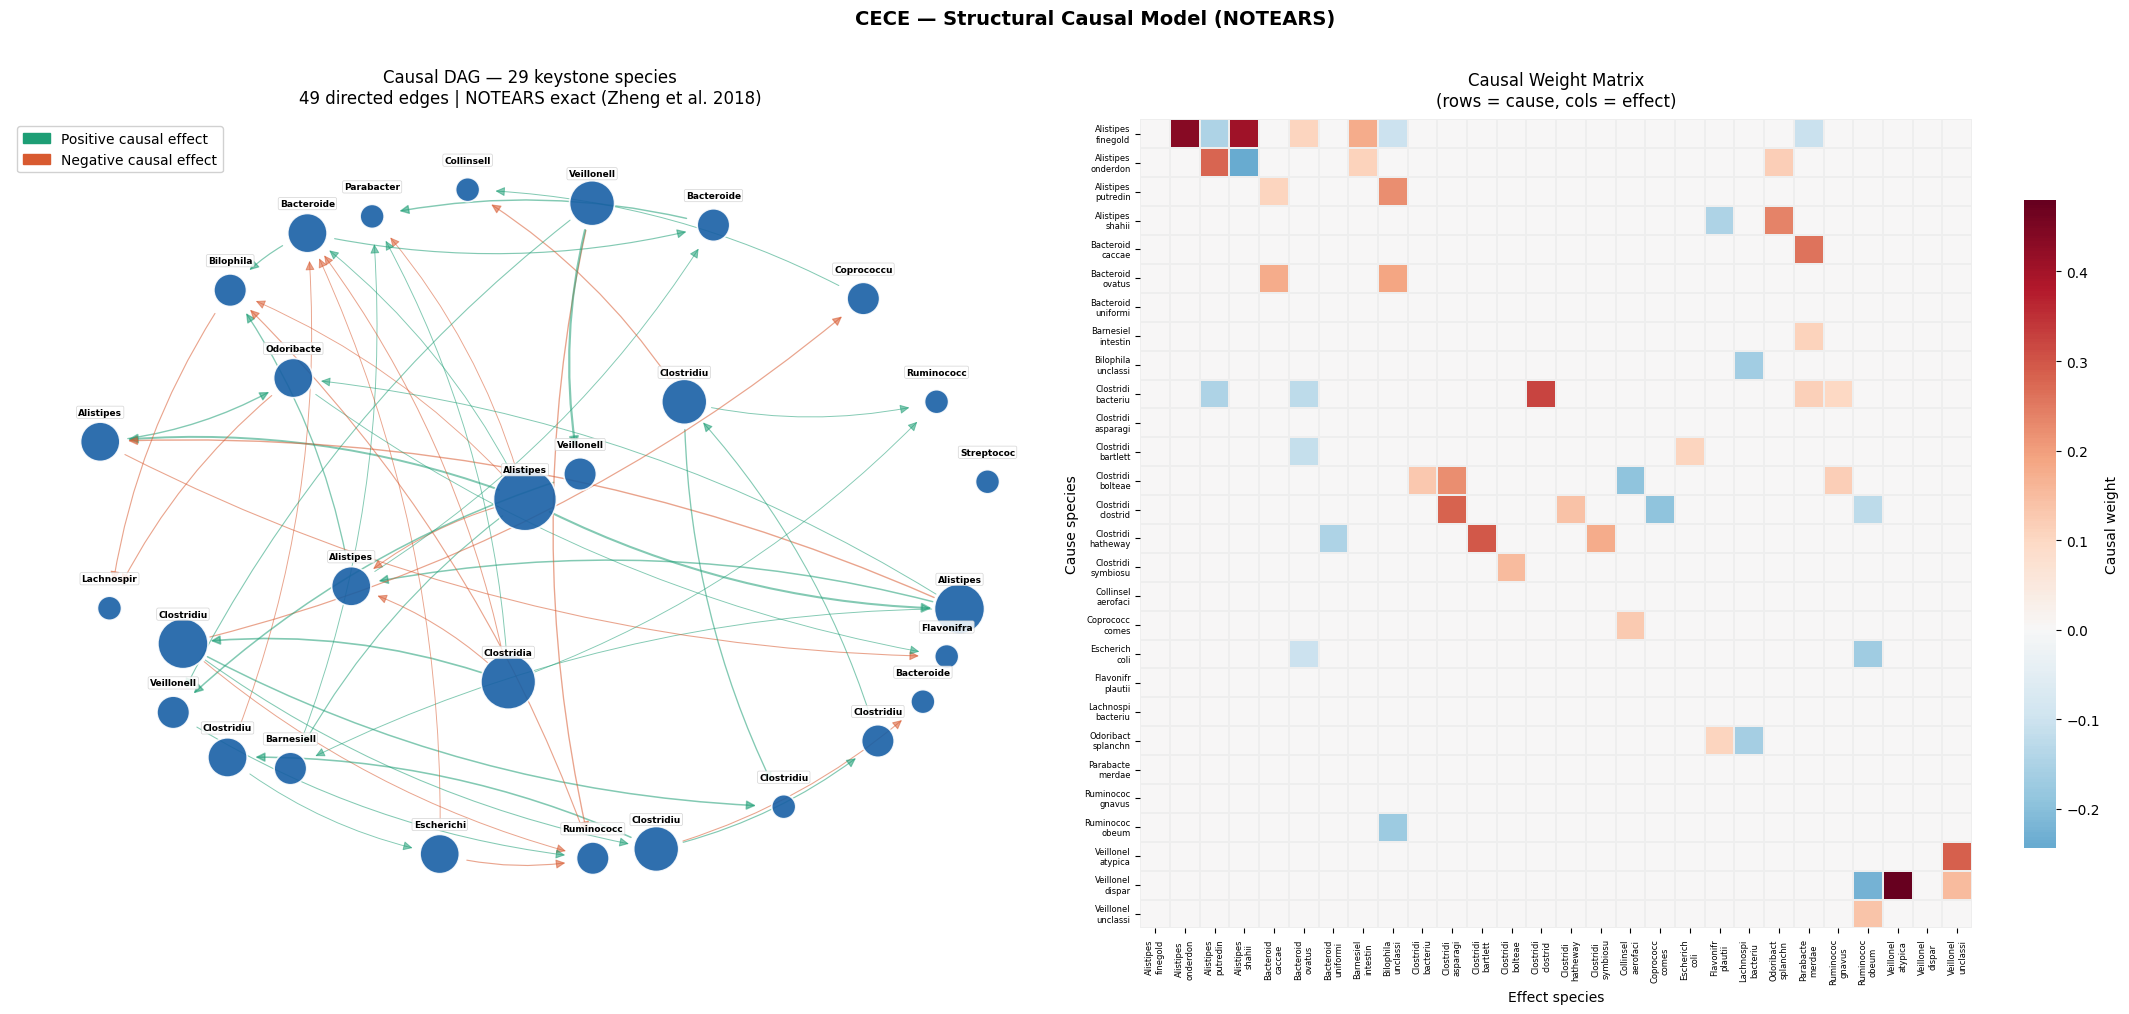

Fig_causal_DAG.png saved


In [10]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(22, 10))

ax = axes[0]
ax.set_facecolor('white')
fig.patch.set_facecolor('white')

pos = nx.spring_layout(G_dag, k=3.5, iterations=300, seed=42, scale=2.5)

min_dist = 0.35
for _ in range(50):
    for n1 in list(pos.keys()):
        for n2 in list(pos.keys()):
            if n1 == n2:
                continue
            p1 = np.array(pos[n1])
            p2 = np.array(pos[n2])
            d  = np.linalg.norm(p1 - p2)
            if d < min_dist and d > 0:
                direction = (p1 - p2) / d
                pos[n1]   = tuple(p1 + direction * (min_dist - d) * 0.5)
                pos[n2]   = tuple(p2 - direction * (min_dist - d) * 0.5)

out_deg    = dict(G_dag.out_degree())
node_sizes = [300 + 250 * out_deg.get(n, 0) for n in G_dag.nodes()]

edge_colors = []
edge_widths = []
for u, v in G_dag.edges():
    w = G_dag[u][v].get('weight', 0)
    edge_colors.append('#1D9E75' if w > 0 else '#D85A30')
    edge_widths.append(0.4 + 2.5 * abs(w))

nx.draw_networkx_nodes(
    G_dag, pos, ax=ax,
    node_size=node_sizes,
    node_color='#185FA5',
    alpha=0.9,
    edgecolors='white',
    linewidths=1.2
)
nx.draw_networkx_edges(
    G_dag, pos, ax=ax,
    edge_color=edge_colors,
    width=edge_widths,
    alpha=0.55,
    arrows=True,
    arrowsize=14,
    arrowstyle='-|>',
    connectionstyle='arc3,rad=0.12',
    min_source_margin=20,
    min_target_margin=20
)

offset = 0.18
for node, (x, y) in pos.items():
    short = node.split('_')[0][:10]
    ax.text(
        x, y + offset,
        short,
        fontsize=6.5,
        fontweight='bold',
        color='black',
        ha='center', va='bottom',
        bbox=dict(
            boxstyle='round,pad=0.18',
            facecolor='white',
            edgecolor='#CCCCCC',
            alpha=0.85,
            linewidth=0.5
        ),
        zorder=5
    )

legend_handles = [
    mpatches.Patch(color='#1D9E75', label='Positive causal effect'),
    mpatches.Patch(color='#D85A30', label='Negative causal effect'),
]
ax.legend(handles=legend_handles, fontsize=10, loc='upper left', framealpha=0.9)
ax.set_title(
    f'Causal DAG — {G_dag.number_of_nodes()} keystone species\n'
    f'{G_dag.number_of_edges()} directed edges | NOTEARS exact (Zheng et al. 2018)',
    fontsize=12, pad=12
)
ax.axis('off')

ax = axes[1]

involved = sorted(set(
    edges_df['cause'].tolist() + edges_df['effect'].tolist()
))

n_inv  = len(involved)
W_sub  = np.zeros((n_inv, n_inv))
sp_idx = {sp: i for i, sp in enumerate(involved)}

for _, row in edges_df.iterrows():
    if row['cause'] in sp_idx and row['effect'] in sp_idx:
        W_sub[sp_idx[row['cause']], sp_idx[row['effect']]] = row['weight']

labels_short = [
    sp.split('_')[0][:9] + '\n' + sp.split('_')[1][:8]
    if len(sp.split('_')) > 1 else sp[:12]
    for sp in involved
]

sns.heatmap(
    W_sub,
    xticklabels=labels_short,
    yticklabels=labels_short,
    center=0,
    cmap='RdBu_r',
    ax=ax,
    cbar_kws={'label': 'Causal weight', 'shrink': 0.8},
    linewidths=0.25,
    linecolor='#EEEEEE'
)

ax.set_title('Causal Weight Matrix\n(rows = cause, cols = effect)',
             fontsize=12, pad=10)
ax.set_xlabel('Effect species', fontsize=10)
ax.set_ylabel('Cause species', fontsize=10)
ax.tick_params(axis='x', labelsize=6, rotation=90)
ax.tick_params(axis='y', labelsize=6, rotation=0)

plt.suptitle('CECE — Structural Causal Model (NOTEARS)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/content/Fig_causal_DAG.png', dpi=300,
            bbox_inches='tight', facecolor='white')
plt.show()
print('Fig_causal_DAG.png saved')

In [11]:
import pandas as pd
import shutil
import os

save_dir = f'{SAVE_PATH}/causal'
os.makedirs(save_dir, exist_ok=True)

W_df = pd.DataFrame(W_est, index=keystone_species, columns=keystone_species)
W_df.to_csv(f'{save_dir}/W_est.csv')
print(f'W_est.csv saved: {W_df.shape}')

W_thresh_df = pd.DataFrame(W_est.copy(), index=keystone_species, columns=keystone_species)
W_thresh_df.to_csv(f'{save_dir}/W_est_thresholded.csv')
print(f'W_est_thresholded.csv saved')

edges_to_save = pd.DataFrame([
    {
        'cause':     u,
        'effect':    v,
        'weight':    round(G_dag[u][v]['weight'], 4),
        'direction': 'positive' if G_dag[u][v]['weight'] > 0 else 'negative'
    }
    for u, v in G_dag.edges()
]).sort_values('weight', key=abs, ascending=False).reset_index(drop=True)

edges_to_save.to_csv(f'{save_dir}/causal_edges.csv', index=False)
print(f'causal_edges.csv saved: {len(edges_to_save)} edges  (should be 49)')

pd.Series(keystone_species).to_csv(
    f'{save_dir}/notears_keystone_species.csv',
    index=False, header=False
)
print(f'notears_keystone_species.csv saved: {len(keystone_species)} species')

shutil.copy('/content/Fig_causal_DAG.png', f'{save_dir}/Fig_causal_DAG.png')
print(f'Fig_causal_DAG.png saved to Drive')

print(f'\nAll saved to: {save_dir}')
print(os.listdir(save_dir))

W_est.csv saved: (29, 29)
W_est_thresholded.csv saved
causal_edges.csv saved: 49 edges  (should be 49)
notears_keystone_species.csv saved: 29 species
Fig_causal_DAG.png saved to Drive

All saved to: /content/drive/MyDrive/CECE_results/causal
['W_est.csv', 'W_est_thresholded.csv', 'notears_keystone_species.csv', 'causal_edges.csv', 'Fig_causal_DAG.png']


In [12]:
from google.colab import files

for fname in ['W_est.csv', 'W_est_thresholded.csv',
               'causal_edges.csv', 'notears_keystone_species.csv']:
    files.download(f'{save_dir}/{fname}')
    print(f'Downloading {fname}...')

files.download('/content/Fig_causal_DAG.png')

print('\nPut all CSV files in: data/processed/causal/')
print('Put Fig_causal_DAG.png in: figures/final/')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Put all CSV files in: data/processed/causal/
Put Fig_causal_DAG.png in: figures/final/
